* AI-Driven Phishing Email Detection

│
├── 1. Collect Dataset
│
├── 2. Data Cleaning
│      Remove HTML
│      Lowercase
│      Remove punctuation
│      Remove stopwords
│      Lemmatization
│
├── 3. Feature Engineering
│      TF-IDF
│      URL count
│      Number of digits
│      Sender domain
│      Email length
│      Suspicious keywords
│
├── 4. Train Models
│      Logistic Regression
│      Naive Bayes
│      Random Forest
│      Neural Network (MLPClassifier)
│
├── 5. Compare Models
│
├── 6. Visualizations
│      Confusion Matrix
│      ROC Curve
│      Feature Importance
│
└── 7. Deploy using Flask


In [ ]:
AI-Driven-Phishing-Email-Detection/

│
├── dataset/
│      phishing_email.csv
│
├── notebook/
│      phishing_detection.ipynb
│
├── models/
│      model.pkl
│      vectorizer.pkl
│
├── app/
│      app.py
│      templates/
│            index.html
│      static/
│            style.css
│
├── images/
│      confusion_matrix.png
│      roc_curve.png
│      feature_importance.png
│
├── requirements.txt
├── README.md
└── Project_Report.pdf

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

In [11]:
import pandas as pd
df=pd.read_csv("phishing_email.csv")
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [12]:
print(df.shape)
df.info
df.describe
df['label'].value_counts()

(82486, 2)


label
1    42891
0    39595
Name: count, dtype: int64

In [13]:
df.isnull().sum()

text_combined    0
label            0
dtype: int64

In [14]:
print("Duplicates:",df.duplicated().sum())

Duplicates: 408


In [15]:
df.drop_duplicates(inplace=True)

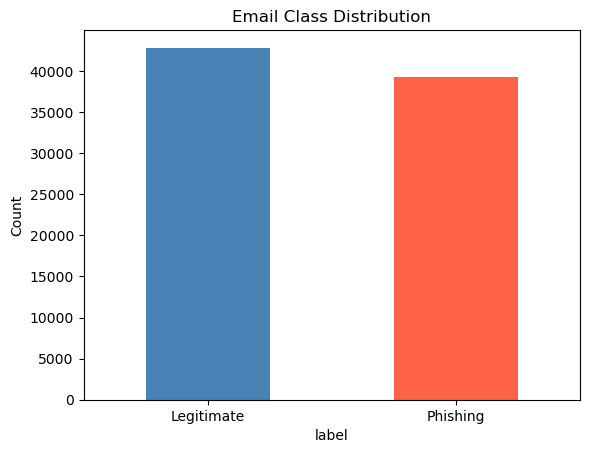

In [17]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(
    kind='bar',
    color=['steelblue','tomato']
)

plt.xticks([0,1],['Legitimate','Phishing'], rotation=0)

plt.ylabel("Count")

plt.title("Email Class Distribution")

plt.show()

In [18]:
df["email_length"] = df["text_combined"].apply(len)

df["email_length"].describe()

count    8.207800e+04
mean     1.290496e+03
std      1.553506e+04
min      1.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.339000e+03
max      4.279526e+06
Name: email_length, dtype: float64

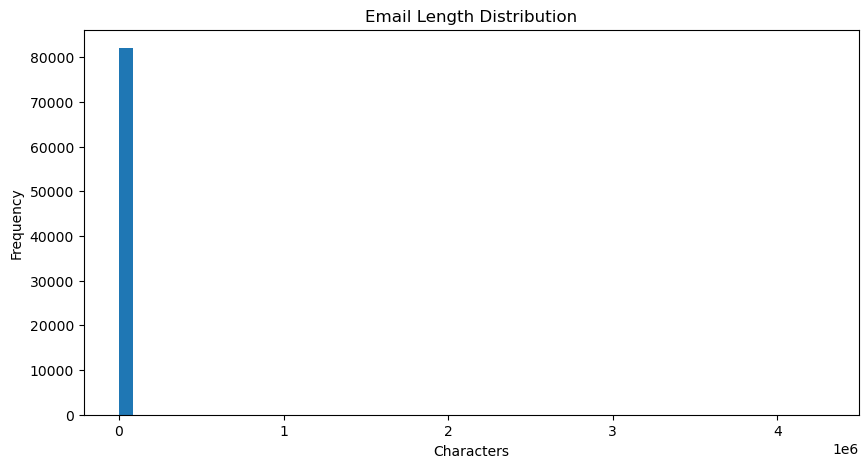

In [19]:
plt.figure(figsize=(10,5))

plt.hist(df["email_length"], bins=50)

plt.title("Email Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [20]:
df.groupby("label")["email_length"].mean()

label
0    1541.456147
1    1060.692520
Name: email_length, dtype: float64

In [22]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to C:\Users\adv
[nltk_data]     danish\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\adv
[nltk_data]     danish\AppData\Roaming\nltk_data...


True

In [23]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [24]:
def preprocess(text):

    words = []

    for word in text.split():

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            words.append(word)

    return " ".join(words)

In [25]:
df["clean_text"] = df["text_combined"].apply(preprocess)

In [26]:
df[["text_combined","clean_text"]].head()

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may 25 2001 see attached file hplno 52...
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols 24 th forwarded sabrae zajac h...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march 30 april 1 201 estimated a...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may 30 2001 see attached file hplno 53...
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june 1 2001 see attached file hplno 60...


In [27]:
X = df["clean_text"]

y = df["label"]

In [28]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(X)

In [29]:
print(X.shape)

(82078, 5000)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
print(X_train.shape)
print(X_test.shape)

(65662, 5000)
(16416, 5000)


In [32]:
import re

def count_urls(text):
    pattern = r'(https?://\S+|www\.\S+)'
    return len(re.findall(pattern, text))

df["url_count"] = df["text_combined"].apply(count_urls)

In [33]:
def count_emails(text):
    pattern = r'[\w\.-]+@[\w\.-]+'
    return len(re.findall(pattern, text))

df["email_count"] = df["text_combined"].apply(count_emails)

In [34]:
def digit_count(text):
    return sum(c.isdigit() for c in text)

df["digit_count"] = df["text_combined"].apply(digit_count)

In [35]:
df["exclamation_count"] = df["text_combined"].str.count("!")

In [36]:
keywords = [
    "verify",
    "account",
    "password",
    "login",
    "click",
    "urgent",
    "bank",
    "security",
    "limited",
    "winner",
    "prize",
    "update",
    "confirm",
    "gift",
    "payment",
    "invoice",
    "alert",
    "bitcoin",
    "refund"
]

def suspicious_count(text):
    text = text.lower()
    return sum(text.count(word) for word in keywords)

df["suspicious_count"] = df["text_combined"].apply(suspicious_count)

In [37]:
def uppercase_words(text):
    return sum(word.isupper() for word in text.split())

df["uppercase_count"] = df["text_combined"].apply(uppercase_words)

In [38]:
df["email_length"] = df["text_combined"].str.len()

In [39]:
from scipy.sparse import hstack

metadata = df[
    [
        "url_count",
        "email_count",
        "digit_count",
        "exclamation_count",
        "suspicious_count",
        "uppercase_count",
        "email_length"
    ]
].values

X_text = tfidf.fit_transform(df["clean_text"])

X = hstack([X_text, metadata])

In [ ]:
df["email_length"] = df["text_combined"].str.len()
